# Tester_branch에서 최종 모델 성능 확인 진행

Best Hyper-parameter {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Score 0.9233990147783251


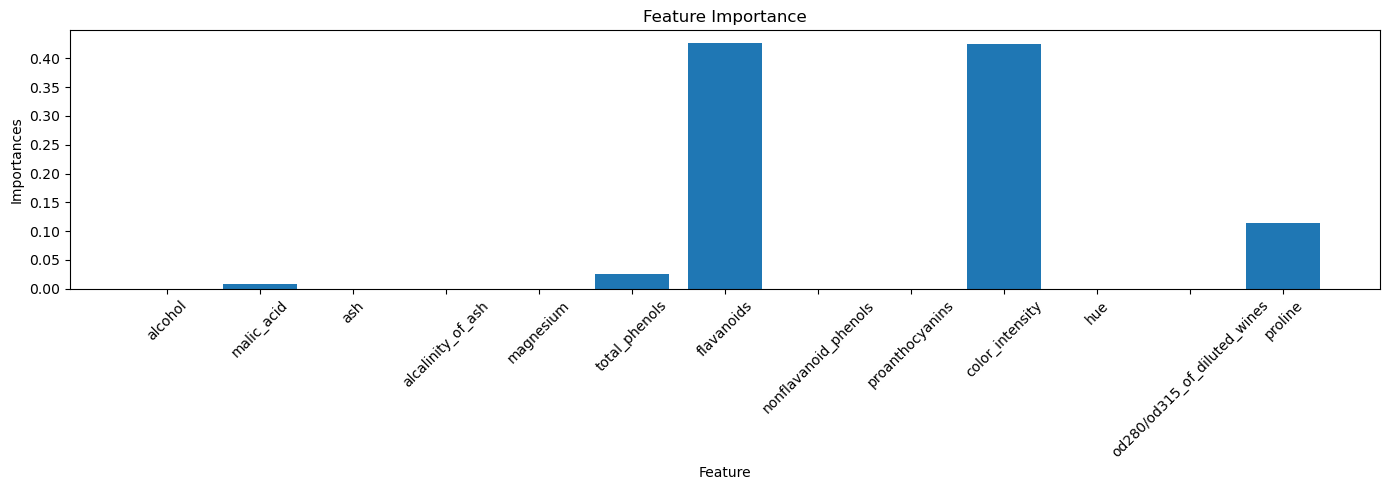

Best Hyper-parameter {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Score 0.9233990147783251


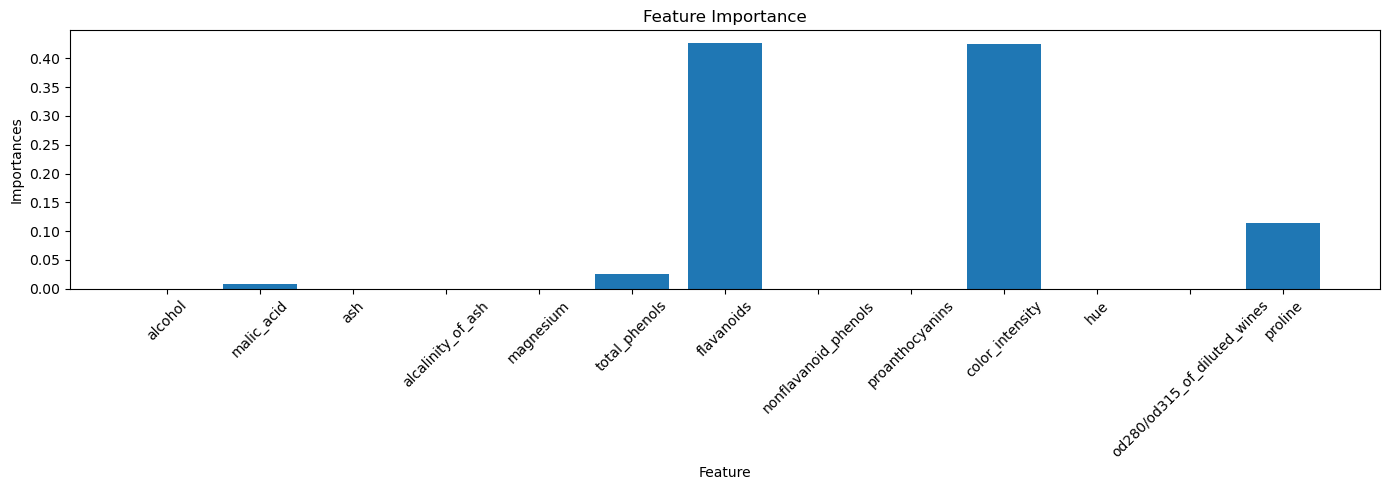

XGB Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
XGB Best Score: 0.951231527093596


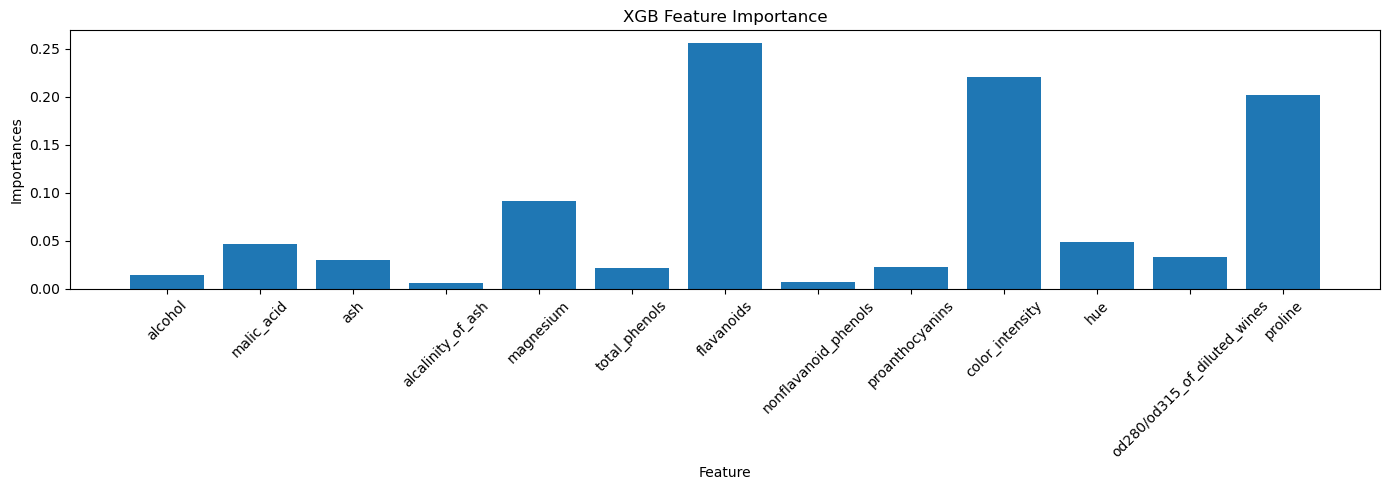

In [6]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()


# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# 데이터프레임 생성
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# feature / target 분리
X = df.drop('target', axis=1)
y = df['target']

# train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

%run 코드_공유.py

# DT 모델링 성능

In [15]:
''' 코드를 작성해주세요 '''
from sklearn.metrics import accuracy_score, classification_report

print("================ DT 성능 확인 ================")

dt_pred = best_dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("DT accuracy :", dt_acc)
print(classification_report(y_test, dt_pred))


================ DT 성능 확인 ================
DT accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

In [13]:
''' 코드를 작성해주세요 '''

print("================ XGB 성능 확인 ================")

xgb_pred = best_xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGB accuracy :", xgb_acc)
print(classification_report(y_test, xgb_pred))

================ XGB 성능 확인 ================
XGB accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

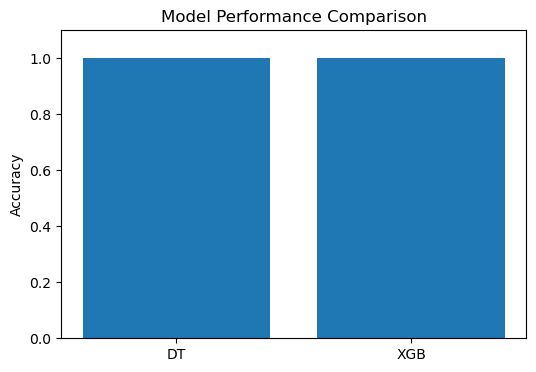

In [14]:
''' 코드를 작성해주세요 '''

import matplotlib.pyplot as plt

models = ['DT', 'XGB']
scores = [dt_acc, xgb_acc]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.show()

In [16]:
print(X_train.shape, X_test.shape)

(142, 13) (36, 13)


<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">